<a href="https://colab.research.google.com/github/hopefulmonstersucla/Structural-Bias-in-Mass-Action-Consumer-Resource-Models/blob/main/Viruses_Mass_Action.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# to do
# make slopes plot axes consistent across systems

In [ ]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange


In [ ]:
# Cell 2: Mount Google Drive and Check File
from google.colab import drive
drive.mount('/content/drive')

# Optionally, check your directory
!ls "/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 global_env_slopes.pdf	     logR_env_panel.pdf
 global_env_slopes_pt.pdf    logR_env_panel_pt.pdf
 global_log10q_plot.pdf      logz_env_panel.pdf
 global_log10R_plot.pdf      q_histogram.pdf
 global_log10R_pt_plot.pdf  'Viruses Mass Action.ipynb'
 global_log10z_plot.pdf     'Wilhelm data BK 20250915 finalised.csv'
 logq_env_panel.pdf	     z_histogram.pdf


In [ ]:
# Cell 3: Load and Inspect Data
file_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/Wilhelm data BK 20250915 finalised.csv'
df = pd.read_csv(file_path)
print(df.head())


   Obs Paper  Ref Winnowed    First author  \
0    1     A             2  Weinbauer, M.    
1    2     A             2  Weinbauer, M.    
2    3     A             2  Weinbauer, M.    
3    4     A             2  Weinbauer, M.    
4    5     A             2  Weinbauer, M.    

                                               Title  \
0  Reconsidering transmission electron microscopy...   
1  Reconsidering transmission electron microscopy...   
2  Reconsidering transmission electron microscopy...   
3  Reconsidering transmission electron microscopy...   
4  Reconsidering transmission electron microscopy...   

                                                Link Environment  \
0  https://www.int-res.com/abstracts/ame/v27/n2/p...       Ocean   
1  https://www.int-res.com/abstracts/ame/v27/n2/p...       Ocean   
2  https://www.int-res.com/abstracts/ame/v27/n2/p...       Ocean   
3  https://www.int-res.com/abstracts/ame/v27/n2/p...       Ocean   
4  https://www.int-res.com/abstracts/ame/v27/n

In [ ]:
# Cell 4: Define Variables and Filter
import numpy as np

# Assign variables from dataframe columns
N = df['Final Cells per mL']
P = df['Final Viruses per mL']
R = df['Final Bacteria lysed per mL']

# Filter for valid, positive, non-missing values
mask = N.notna() & P.notna() & R.notna() & (N > 0) & (P > 0) & (R > 0)

# Apply mask and calculate core variables
N_valid = N[mask].values
P_valid = P[mask].values
R_valid = R[mask].values

# 1. Mass Action (population-level encounter potential)
ma = N_valid * P_valid

# 2. Poisson thinning expectation, assuming z = 1
pt = N_valid * (1 - np.exp(-P_valid / N_valid))

# 3. Required q if mass action is explanatory (observed fraction vs predicted)
req_q = R_valid / (N_valid * P_valid)

# 4. Required z (only where R < N), from Poisson model, "rewrites" q to fit Poisson assumption
mask_z = mask & (R < N)
N_z = N[mask_z].values
P_z = P[mask_z].values
R_z = R[mask_z].values
req_z = -N_z / P_z * np.log(1 - R_z / N_z)


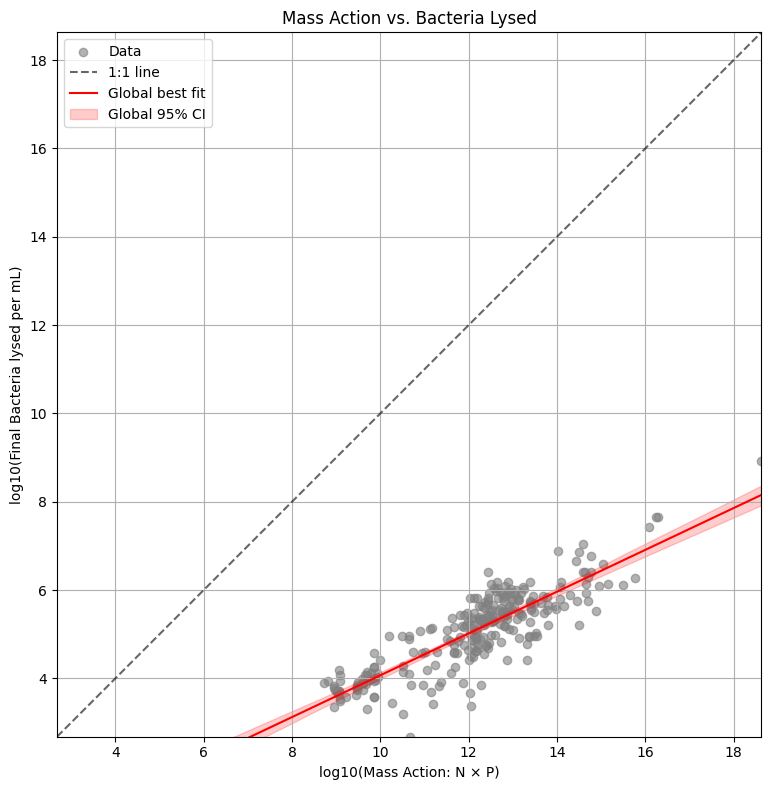

Global best fit slope: 0.4734
Global 95% bootstrap CI for slope: [0.4395, 0.5051]
Global bootstrap R2 mean: 0.7310 (95% CI: 0.6638, 0.7881)


In [ ]:
# Cell 5: Plot log10(R) vs log10(Mass Action) and Output Stats

plt.figure(figsize=(8,8))
plt.scatter(np.log10(ma), np.log10(R_valid), alpha=0.6, label='Data', color='grey')
lims = [min(np.log10(ma).min(), np.log10(R_valid).min()), max(np.log10(ma).max(), np.log10(R_valid).max())]
plt.plot(lims, lims, 'k--', alpha=0.6, label='1:1 line')
plt.xlim(lims)
plt.ylim(lims)

# Fit and bootstrap for the new variable set
slope, intercept = np.polyfit(np.log10(ma), np.log10(R_valid), 1)
n_bootstrap = 1000
slopes = []
intercepts = []
r2 = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(ma), len(ma))
    x_sample = np.log10(ma)[idx]
    y_sample = np.log10(R_valid)[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes.append(s)
    intercepts.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2_ = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2.append(r2_)
x_pred = np.linspace(lims[0], lims[1], 100)
y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
plt.plot(x_pred, slope * x_pred + intercept, color='red', label='Global best fit')
plt.fill_between(x_pred, y_low, y_high, color='red', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Mass Action: N × P)')
plt.ylabel('log10(Final Bacteria lysed per mL)')
plt.title('Mass Action vs. Bacteria Lysed')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_log10R_plot.pdf', bbox_inches='tight')
plt.show()

slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
r2_mean = np.nanmean(r2)
r2_lo, r2_hi = np.nanpercentile(r2, [2.5, 97.5])

print(f"Global best fit slope: {slope:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_lo:.4f}, {slope_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_mean:.4f} (95% CI: {r2_lo:.4f}, {r2_hi:.4f})")




log10(R) Bootstrapped Slopes & R2:
Estuary   : slope=0.383 [0.281,0.490], R2=0.617 [0.460,0.744], n=46
Lagoon    : slope=0.647 [0.604,0.723], R2=0.988 [0.965,0.998], n=9
Lake      : slope=0.322 [0.107,0.584], R2=0.504 [0.034,0.953], n=8
Ocean     : slope=0.477 [0.440,0.517], R2=0.667 [0.596,0.737], n=197


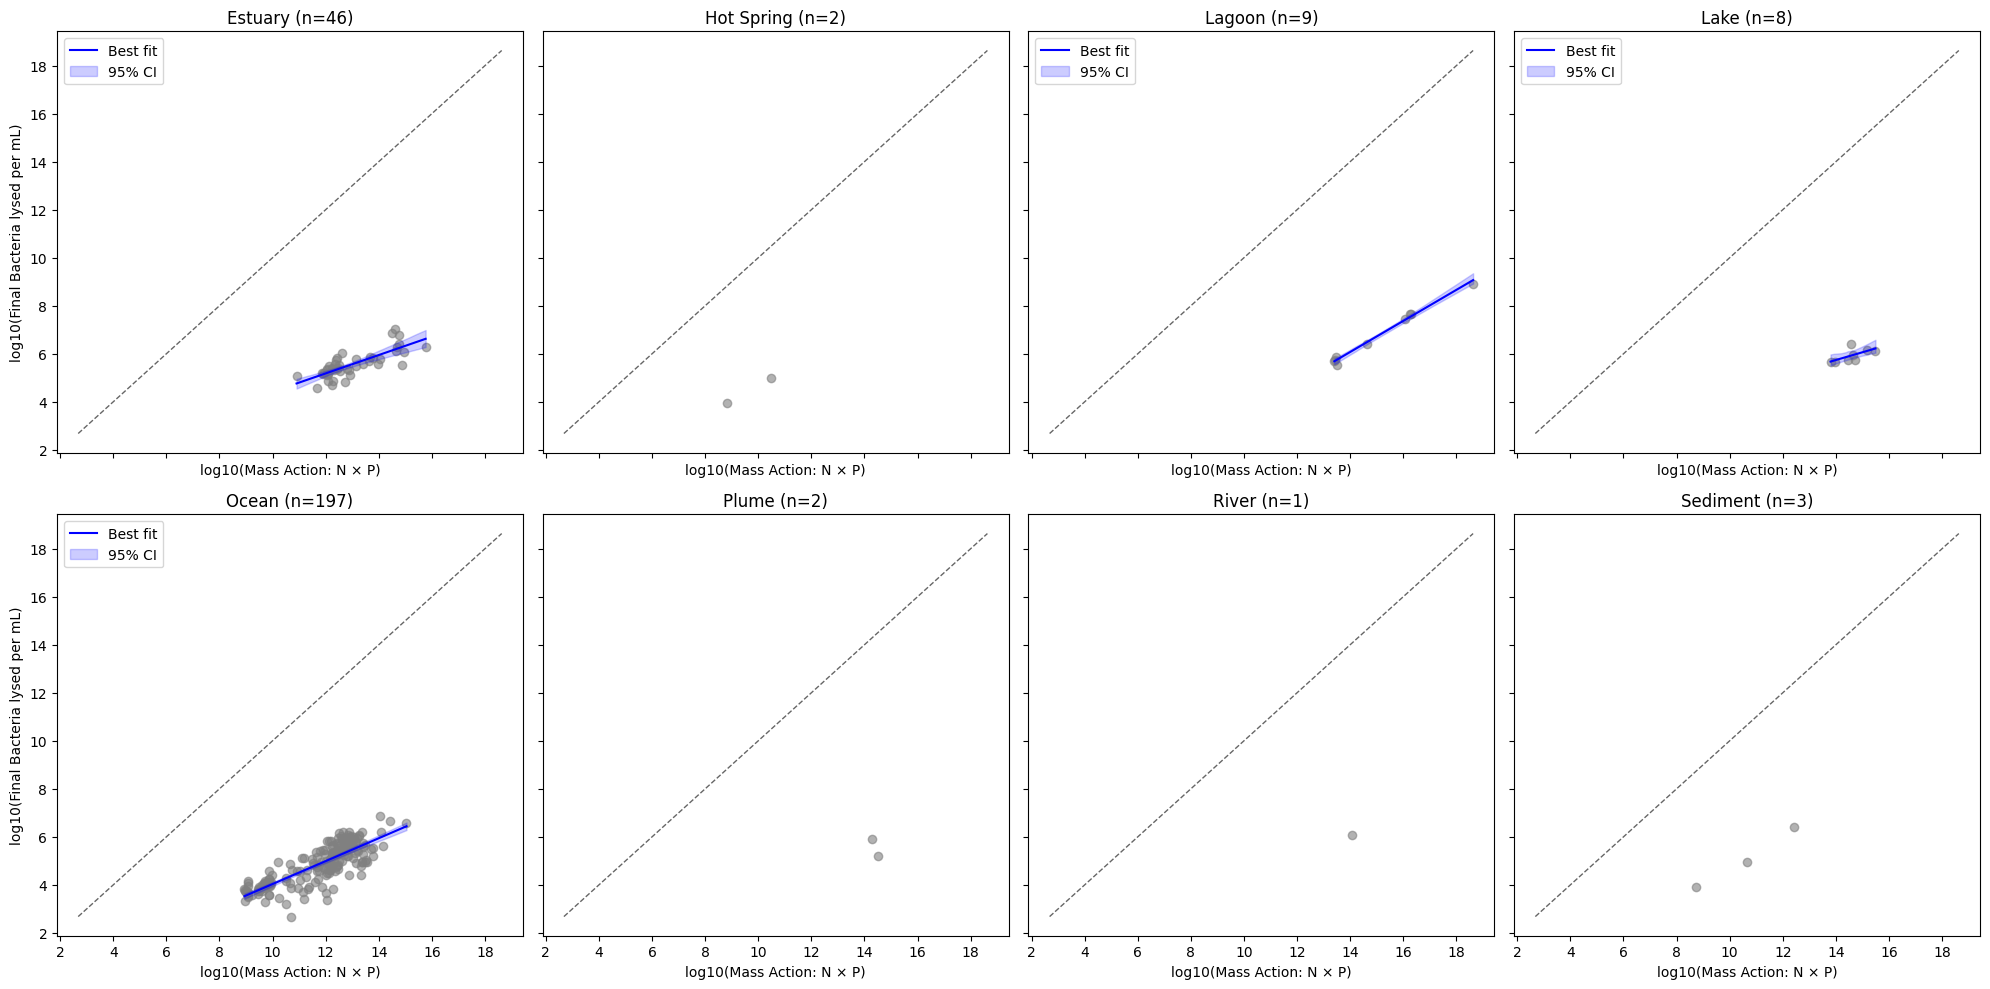

In [ ]:
#Cell 9: Faceting R plots by environment
env_list = np.unique(env)
n_bootstrap = 1000
ncol = 4
nrow = int(np.ceil(len(env_list) / ncol))

x_all = np.log10(ma)
y_all = np.log10(R_valid)
lims = [min(x_all.min(), y_all.min()), max(x_all.max(), y_all.max())]

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(R) Bootstrapped Slopes & R2:')
for i, e in enumerate(env_list):
    idx = np.where(env == e)[0]
    ax = axes[i]
    x_env = x_all[idx]
    y_env = y_all[idx]
    ax.scatter(x_env, y_env, color='grey', alpha=0.6)
    ax.plot(lims, lims, 'k--', alpha=0.6, lw=1)  # 1:1 line
    ax.set_title(f"{e} (n={len(x_env)})")
    ax.set_xlabel('log10(Mass Action: N × P)')
    if i % ncol == 0:
        ax.set_ylabel('log10(Final Bacteria lysed per mL)')
    if len(x_env) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_env), len(x_env))
            x_boot = x_env[boot_idx]
            y_boot = y_env[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred)**2)
            ss_tot = np.sum((y_boot - np.mean(y_boot))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(x_env.min(), x_env.max(), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{e:10}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_env)}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/logR_env_panel.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()






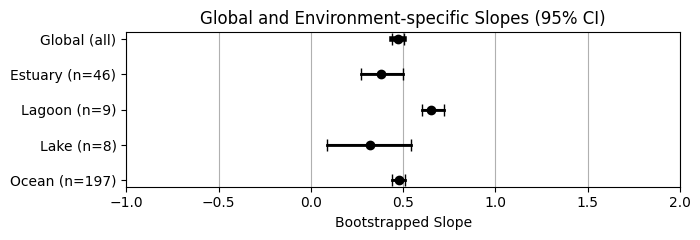

Slope Summary:
Global      : mean=0.4724, 95% CI=(0.4408, 0.5052), all
Estuary     : mean=0.3829, 95% CI=(0.2742, 0.4976), n=46
Lagoon      : mean=0.6504, 95% CI=(0.6026, 0.7235), n=9
Lake        : mean=0.3206, 95% CI=(0.0890, 0.5435), n=8
Ocean       : mean=0.4770, 95% CI=(0.4408, 0.5129), n=197


In [ ]:
# Cell 7: Plot bootstrap slopes for global and environmental bins

x_ma = np.log10(ma)
y_R = np.log10(R_valid)
env = df.loc[mask, 'Environment'].values  # Ensure this matches your filtered rows
env_list = np.unique(env)
n_bootstrap = 1000

# Global bootstrap slope and CI
global_slopes = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x_ma), len(x_ma))
    s, _ = np.polyfit(x_ma[idx], y_R[idx], 1)
    global_slopes.append(s)
global_mean = np.mean(global_slopes)
global_lo, global_hi = np.percentile(global_slopes, [2.5, 97.5])

# Environment bootstrap slopes and CIs
env_names = []
env_means = []
env_los = []
env_his = []
env_ns = []

for e in env_list:
    idx_group = np.where(env == e)[0]
    if len(idx_group) >= 5:
        xg = x_ma[idx_group]
        yg = y_R[idx_group]
        slopes = []
        for _ in range(n_bootstrap):
            idx_bs = np.random.randint(0, len(xg), len(xg))
            s_bs, _ = np.polyfit(xg[idx_bs], yg[idx_bs], 1)
            slopes.append(s_bs)
        env_names.append(e)
        env_means.append(np.mean(slopes))
        lo, hi = np.percentile(slopes, [2.5, 97.5])
        env_los.append(lo)
        env_his.append(hi)
        env_ns.append(len(xg))

# Plotting
plt.figure(figsize=(7, 0.5 + 0.5*len(env_means)))
labels = ['Global'] + env_names
means = [global_mean] + env_means
los = [global_lo] + env_los
his = [global_hi] + env_his
sizes = ['all'] + [f'n={n}' for n in env_ns]

y_pos = np.arange(len(means))
plt.errorbar(means, y_pos, xerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)], fmt='o', capsize=4, color='black')
for i, (mean, lo, hi) in enumerate(zip(means, los, his)):
    plt.plot([lo, hi], [y_pos[i]]*2, color='black', lw=4 if i==0 else 2)
plt.yticks(y_pos, [f'{labels[i]} ({sizes[i]})' for i in range(len(labels))])
plt.xlabel('Bootstrapped Slope')
plt.title('Global and Environment-specific Slopes (95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.xlim(-1, 2)
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_env_slopes.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()

# Printout table:
print("Slope Summary:")
for i, label in enumerate(labels):
    print(f"{label:12}: mean={means[i]:.4f}, 95% CI=({los[i]:.4f}, {his[i]:.4f}), {sizes[i]}")


100%|██████████| 1000/1000 [00:00<00:00, 6716.01it/s]


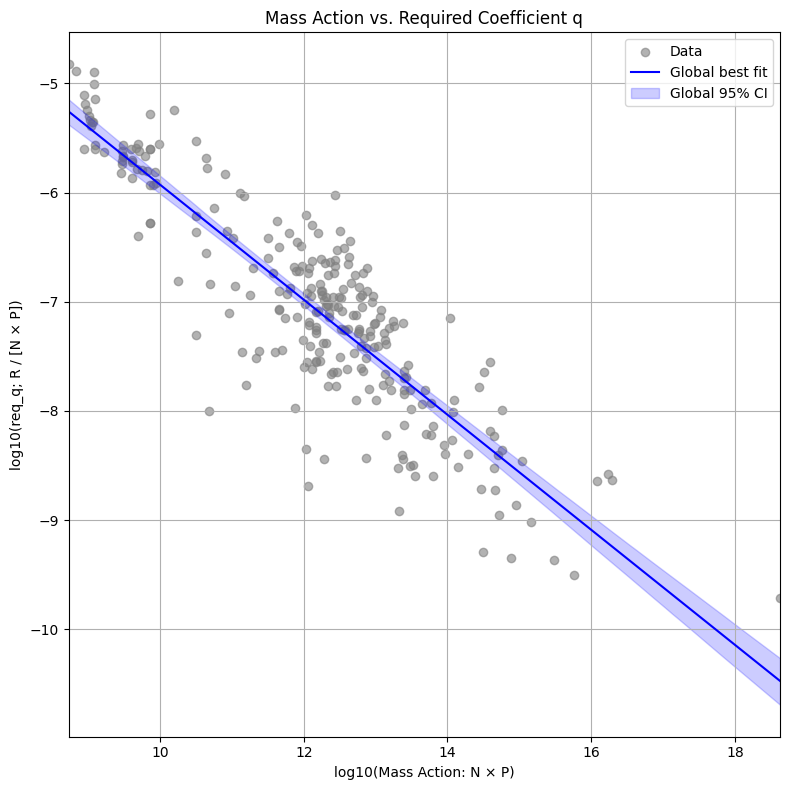

Global best fit slope: -0.5266
Global 95% bootstrap CI for slope: [-0.5583, -0.4962]
Global bootstrap R2 mean: 0.7708 (95% CI: 0.7117, 0.8203)


In [ ]:
# Cell 6: Plot log10(req_q) and Output Stats

x_q = np.log10(ma)
y_req_q = np.log10(req_q)

plt.figure(figsize=(8,8))
plt.scatter(x_q, y_req_q, alpha=0.6, label='Data', color='grey')
lims_q = [min(x_q), max(x_q)]
plt.xlim(lims_q)

slope_q, intercept_q = np.polyfit(x_q, y_req_q, 1)
n_bootstrap = 1000
slopes_q = []
intercepts_q = []
r2_q = []
for _ in trange(n_bootstrap):
    idx = np.random.randint(0, len(x_q), len(x_q))
    x_sample = x_q[idx]
    y_sample = y_req_q[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes_q.append(s)
    intercepts_q.append(b)
    # R^2 calculation for each bootstrap regression
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_q.append(r2)

x_pred_q = np.linspace(lims_q[0], lims_q[1], 100)
y_pred_mat_q = np.array([s * x_pred_q + b for s, b in zip(slopes_q, intercepts_q)])
y_low_q, y_high_q = np.percentile(y_pred_mat_q, [2.5, 97.5], axis=0)
plt.plot(x_pred_q, slope_q * x_pred_q + intercept_q, color='blue', label='Global best fit')
plt.fill_between(x_pred_q, y_low_q, y_high_q, color='blue', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Mass Action: N × P)')
plt.ylabel('log10(req_q; R / [N × P])')
plt.title('Mass Action vs. Required Coefficient q')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_log10q_plot.pdf', bbox_inches='tight')
plt.show()

slope_q_lo, slope_q_hi = np.percentile(slopes_q, [2.5, 97.5])
r2_q_mean = np.nanmean(r2_q)
r2_q_lo, r2_q_hi = np.nanpercentile(r2_q, [2.5, 97.5])

print(f"Global best fit slope: {slope_q:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_q_lo:.4f}, {slope_q_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_q_mean:.4f} (95% CI: {r2_q_lo:.4f}, {r2_q_hi:.4f})")


Mean log10(req_q):   -7.0585 [-7.1787, -6.9345]
Median log10(req_q): -7.0939 [-7.2273, -6.9604]
Mode log10(req_q):   -7.0839 [-7.6148, -6.6992]


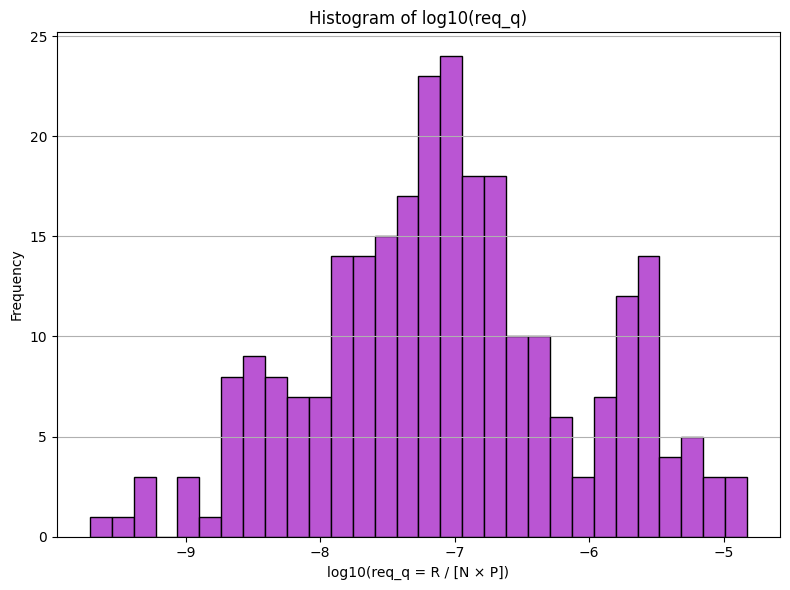

In [ ]:
# Cell 8: Plot histogram of q frequencies
# Filter req_q values
qvals = req_q  # Already filtered by mask in earlier block
qvals = qvals[qvals > 0]
logq = np.log10(qvals)
n_bootstrap = 1000

# Bootstrapped mean, median, mode
means = []
medians = []
modes = []

for _ in range(n_bootstrap):
    sample = np.random.choice(logq, size=len(logq), replace=True)
    means.append(np.mean(sample))
    medians.append(np.median(sample))
    hist, bin_edges = np.histogram(sample, bins=30)
    mode_idx = np.argmax(hist)
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    modes.append(mode_val)

mean_val = np.mean(means)
mean_lo, mean_hi = np.percentile(means, [2.5, 97.5])
median_val = np.mean(medians)
median_lo, median_hi = np.percentile(medians, [2.5, 97.5])
mode_val = np.mean(modes)
mode_lo, mode_hi = np.percentile(modes, [2.5, 97.5])

print(f"Mean log10(req_q):   {mean_val:.4f} [{mean_lo:.4f}, {mean_hi:.4f}]")
print(f"Median log10(req_q): {median_val:.4f} [{median_lo:.4f}, {median_hi:.4f}]")
print(f"Mode log10(req_q):   {mode_val:.4f} [{mode_lo:.4f}, {mode_hi:.4f}]")

# Histogram plot
plt.figure(figsize=(8,6))
plt.hist(logq, bins=30, color='mediumorchid', edgecolor='black')
plt.xlabel('log10(req_q = R / [N × P])')
plt.ylabel('Frequency')
plt.title('Histogram of log10(req_q)')
plt.grid(axis='y')
plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/q_histogram.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()



log10(req_q) Bootstrapped Slopes & R2:
Estuary   : slope=-0.617 [-0.718,-0.503], R2=0.805 [0.679,0.905], n=46
Lagoon    : slope=-0.351 [-0.396,-0.275], R2=0.960 [0.874,0.993], n=9
Lake      : slope=-0.681 [-0.872,-0.478], R2=0.759 [0.270,0.990], n=8
Ocean     : slope=-0.523 [-0.561,-0.481], R2=0.705 [0.623,0.772], n=197


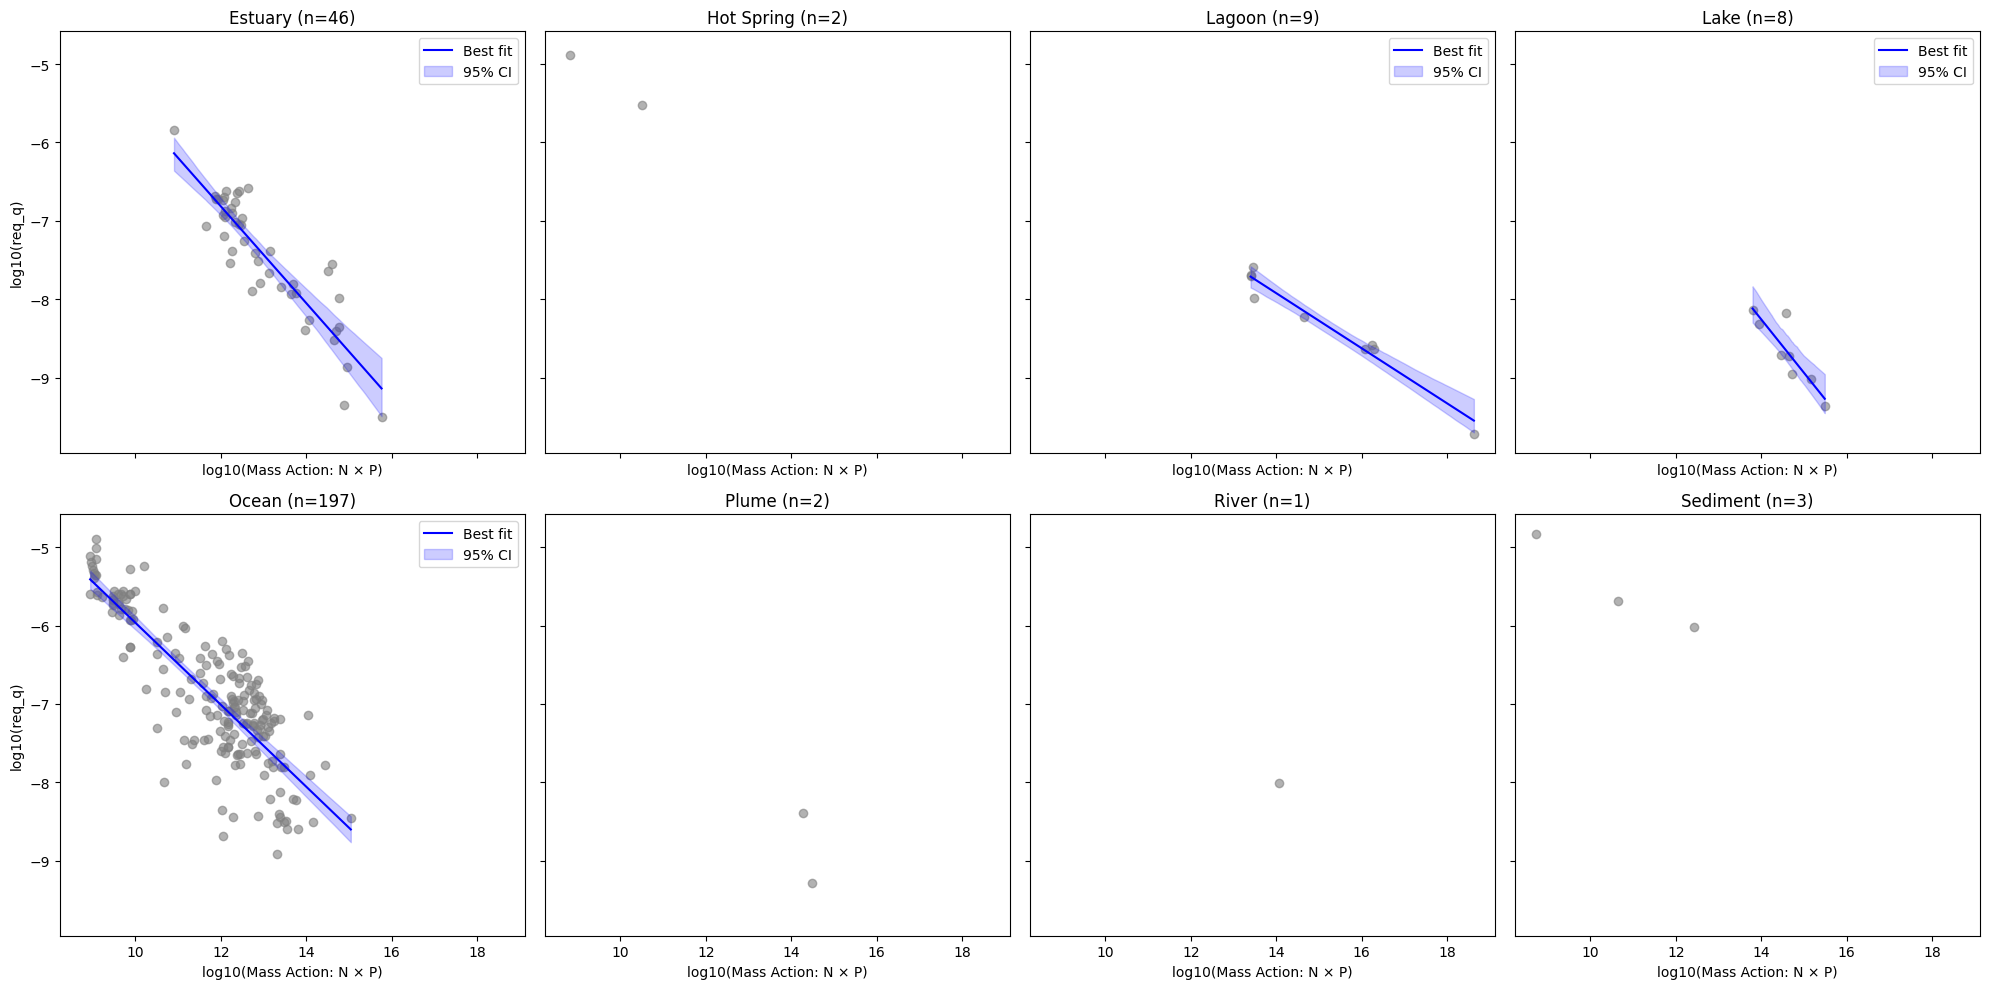

In [ ]:
#Cell 10: Faceting q plots by environment
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(req_q) Bootstrapped Slopes & R2:')
for i, e in enumerate(env_list):
    idx = np.where(env == e)[0]
    ax = axes[i]
    x_env = np.log10(ma)[idx]
    y_env = np.log10(req_q)[idx]
    ax.scatter(x_env, y_env, color='grey', alpha=0.6)
    ax.set_title(f"{e} (n={len(x_env)})")
    ax.set_xlabel('log10(Mass Action: N × P)')
    if i % ncol == 0:
        ax.set_ylabel('log10(req_q)')

    # Best fit if n>=5
    if len(x_env) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_env), len(x_env))
            x_boot = x_env[boot_idx]
            y_boot = y_env[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred) ** 2)
            ss_tot = np.sum((y_boot - np.mean(y_boot)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(min(x_env), max(x_env), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{e:10}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_env)}")

# Hide empty panels
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/logq_env_panel.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()



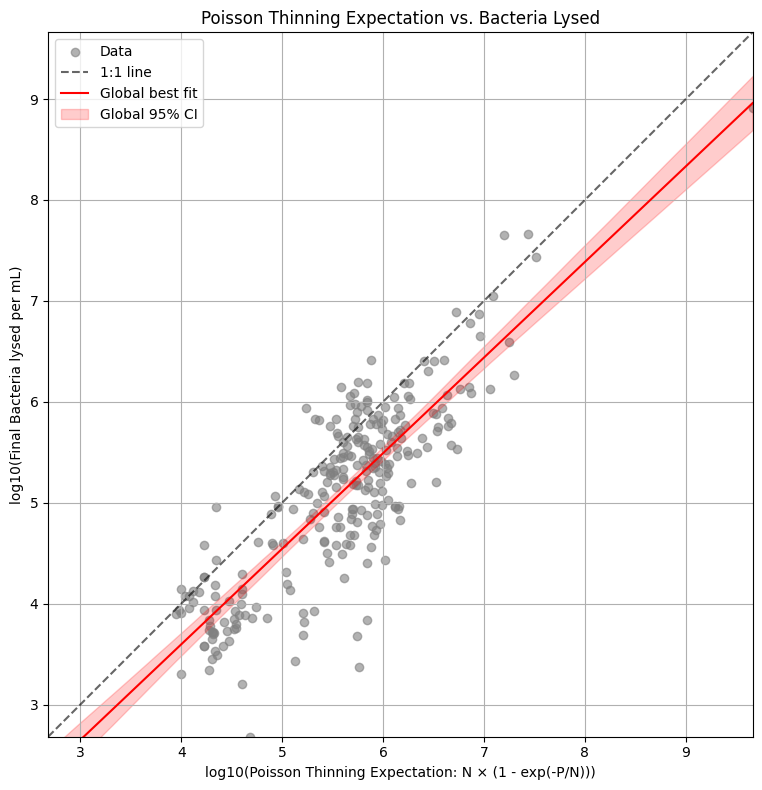

Global best fit slope: 0.9473
Global 95% bootstrap CI for slope: [0.8842, 1.0103]
Global bootstrap R2 mean: 0.7022 (95% CI: 0.6295, 0.7707)


In [ ]:
# Cell 5: Plot log10(R) vs log10(Poisson Thinning Expectation) and Output Stats

plt.figure(figsize=(8,8))
plt.scatter(np.log10(pt), np.log10(R_valid), alpha=0.6, label='Data', color='grey')
lims = [min(np.log10(pt).min(), np.log10(R_valid).min()), max(np.log10(pt).max(), np.log10(R_valid).max())]
plt.plot(lims, lims, 'k--', alpha=0.6, label='1:1 line')
plt.xlim(lims)
plt.ylim(lims)

# Fit and bootstrap for the new variable set
slope, intercept = np.polyfit(np.log10(pt), np.log10(R_valid), 1)
n_bootstrap = 1000
slopes = []
intercepts = []
r2 = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(pt), len(pt))
    x_sample = np.log10(pt)[idx]
    y_sample = np.log10(R_valid)[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes.append(s)
    intercepts.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2_ = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2.append(r2_)
x_pred = np.linspace(lims[0], lims[1], 100)
y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
plt.plot(x_pred, slope * x_pred + intercept, color='red', label='Global best fit')
plt.fill_between(x_pred, y_low, y_high, color='red', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Poisson Thinning Expectation: N × (1 - exp(-P/N)))')
plt.ylabel('log10(Final Bacteria lysed per mL)')
plt.title('Poisson Thinning Expectation vs. Bacteria Lysed')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_log10R_pt_plot.pdf', bbox_inches='tight')
plt.show()

slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
r2_mean = np.nanmean(r2)
r2_lo, r2_hi = np.nanpercentile(r2, [2.5, 97.5])

print(f"Global best fit slope: {slope:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_lo:.4f}, {slope_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_mean:.4f} (95% CI: {r2_lo:.4f}, {r2_hi:.4f})")


log10(R) Bootstrapped Slopes & R2 (Poisson thinning):
Estuary   : slope=0.923 [0.672,1.230], R2=0.603 [0.434,0.739], n=46
Lagoon    : slope=1.143 [0.812,1.801], R2=0.919 [0.816,0.985], n=9
Lake      : slope=0.366 [-0.470,0.872], R2=0.343 [0.001,0.891], n=8
Ocean     : slope=0.967 [0.873,1.056], R2=0.607 [0.516,0.687], n=197


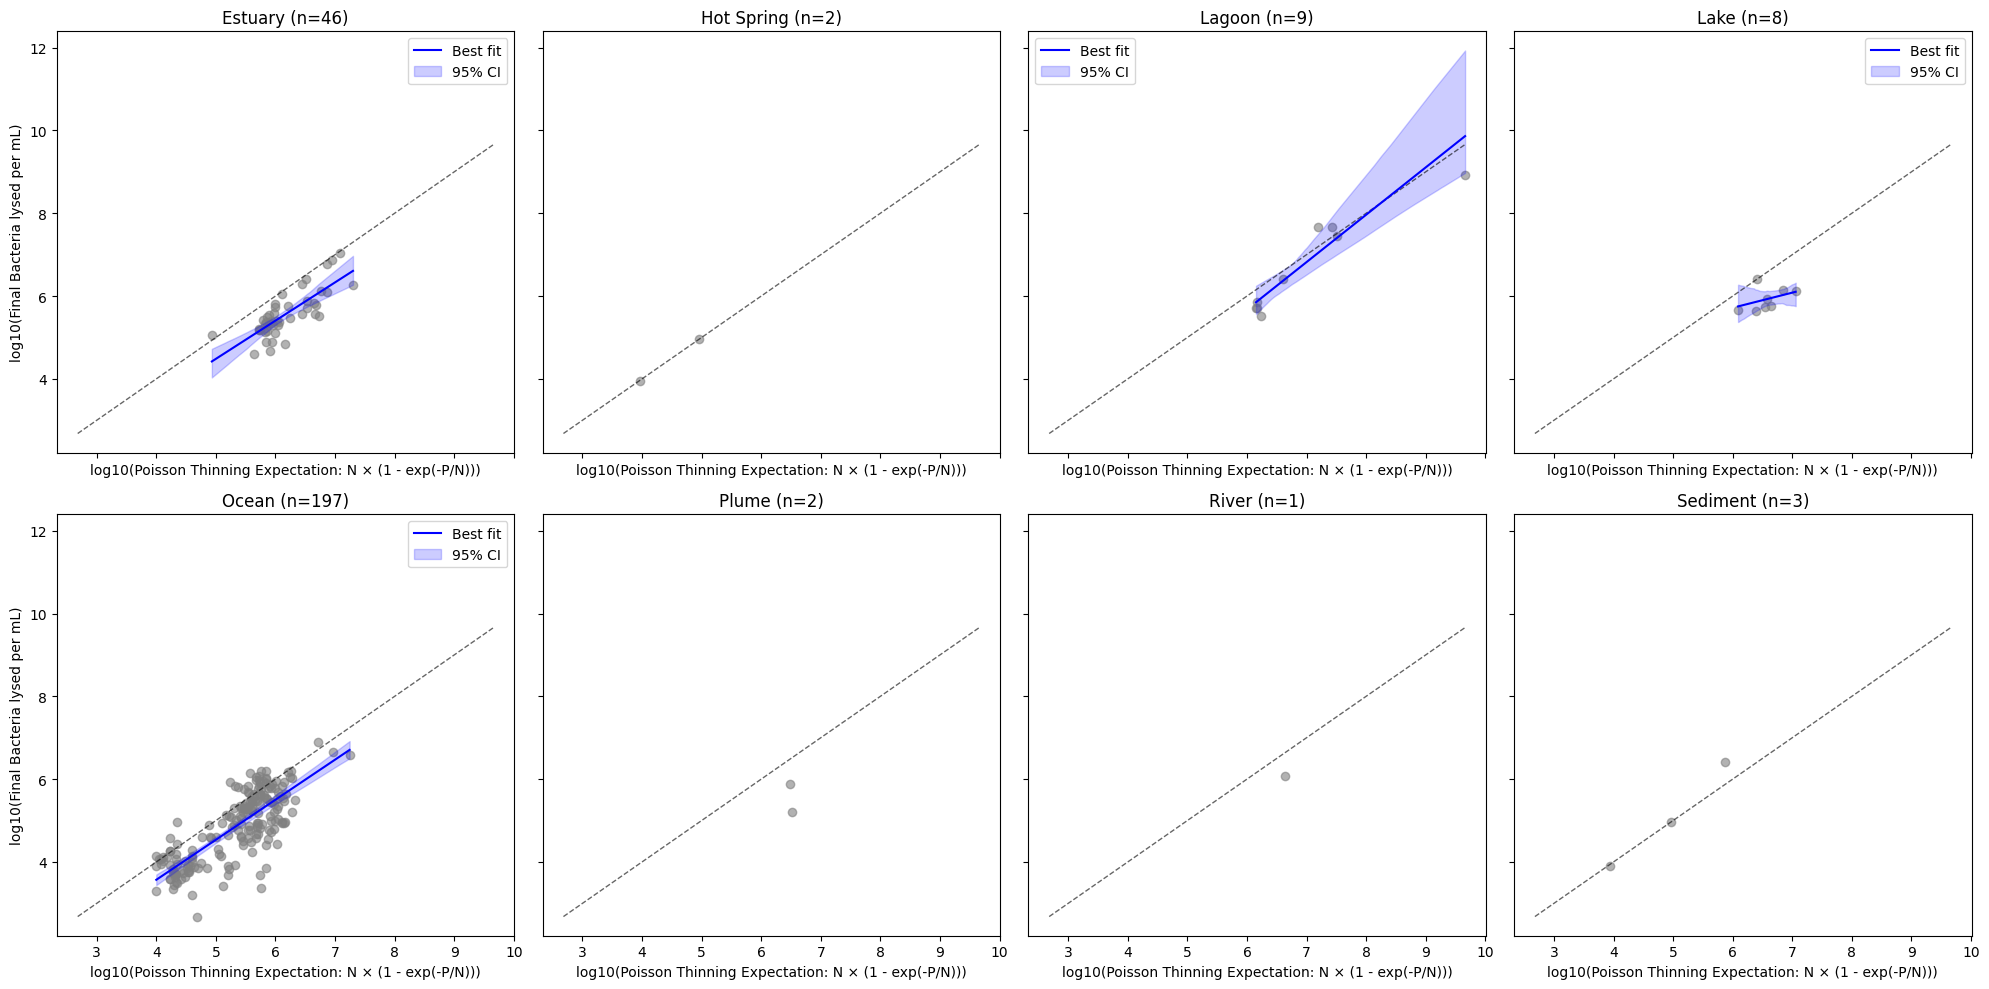

In [ ]:
# Cell 9: Faceting R plots by environment (Poisson thinning model)

import numpy as np
import matplotlib.pyplot as plt

x_all = np.log10(pt)
y_all = np.log10(R_valid)
env = df.loc[mask, 'Environment'].values   # matches pt and R_valid
env_list = np.unique(env)
n_bootstrap = 1000
ncol = 4
nrow = int(np.ceil(len(env_list) / ncol))

lims = [min(x_all.min(), y_all.min()), max(x_all.max(), y_all.max())]

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(R) Bootstrapped Slopes & R2 (Poisson thinning):')
for i, e in enumerate(env_list):
    idx = np.where(env == e)[0]
    ax = axes[i]
    x_env = x_all[idx]
    y_env = y_all[idx]
    ax.scatter(x_env, y_env, color='grey', alpha=0.6)
    ax.plot(lims, lims, 'k--', alpha=0.6, lw=1)  # 1:1 line
    ax.set_title(f"{e} (n={len(x_env)})")
    ax.set_xlabel('log10(Poisson Thinning Expectation: N × (1 - exp(-P/N)))')
    if i % ncol == 0:
        ax.set_ylabel('log10(Final Bacteria lysed per mL)')
    if len(x_env) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_env), len(x_env))
            x_boot = x_env[boot_idx]
            y_boot = y_env[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred)**2)
            ss_tot = np.sum((y_boot - np.mean(y_boot))**2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(x_env.min(), x_env.max(), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{e:10}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_env)}")
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/logR_env_panel_pt.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()


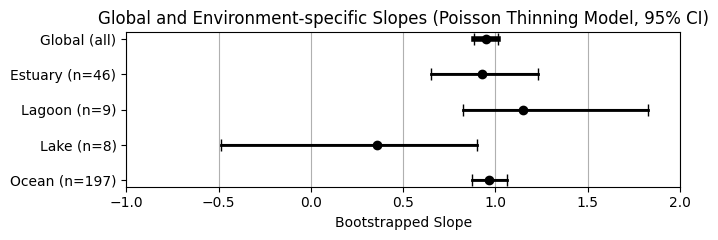

Slope Summary:
Global      : mean=0.9470, 95% CI=(0.8859, 1.0117), all
Estuary     : mean=0.9266, 95% CI=(0.6492, 1.2298), n=46
Lagoon      : mean=1.1516, 95% CI=(0.8224, 1.8249), n=9
Lake        : mean=0.3589, 95% CI=(-0.4887, 0.9003), n=8
Ocean       : mean=0.9663, 95% CI=(0.8750, 1.0608), n=197


In [ ]:
# Cell 7: Plot bootstrap slopes for global and environmental bins (Poisson thinning model)

x_pt = np.log10(pt)
y_R = np.log10(R_valid)
env = df.loc[mask, 'Environment'].values  # Ensure this matches your filtered rows
env_list = np.unique(env)
n_bootstrap = 1000

# Global bootstrap slope and CI
global_slopes = []
for _ in range(n_bootstrap):
    idx = np.random.randint(0, len(x_pt), len(x_pt))
    s, _ = np.polyfit(x_pt[idx], y_R[idx], 1)
    global_slopes.append(s)
global_mean = np.mean(global_slopes)
global_lo, global_hi = np.percentile(global_slopes, [2.5, 97.5])

# Environment bootstrap slopes and CIs
env_names = []
env_means = []
env_los = []
env_his = []
env_ns = []

for e in env_list:
    idx_group = np.where(env == e)[0]
    if len(idx_group) >= 5:
        xg = x_pt[idx_group]
        yg = y_R[idx_group]
        slopes = []
        for _ in range(n_bootstrap):
            idx_bs = np.random.randint(0, len(xg), len(xg))
            s_bs, _ = np.polyfit(xg[idx_bs], yg[idx_bs], 1)
            slopes.append(s_bs)
        env_names.append(e)
        env_means.append(np.mean(slopes))
        lo, hi = np.percentile(slopes, [2.5, 97.5])
        env_los.append(lo)
        env_his.append(hi)
        env_ns.append(len(xg))

# Plotting
plt.figure(figsize=(7, 0.5 + 0.5*len(env_means)))
labels = ['Global'] + env_names
means = [global_mean] + env_means
los = [global_lo] + env_los
his = [global_hi] + env_his
sizes = ['all'] + [f'n={n}' for n in env_ns]

y_pos = np.arange(len(means))
plt.errorbar(means, y_pos, xerr=[np.array(means)-np.array(los), np.array(his)-np.array(means)], fmt='o', capsize=4, color='black')
for i, (mean, lo, hi) in enumerate(zip(means, los, his)):
    plt.plot([lo, hi], [y_pos[i]]*2, color='black', lw=4 if i==0 else 2)
plt.yticks(y_pos, [f'{labels[i]} ({sizes[i]})' for i in range(len(labels))])
plt.xlabel('Bootstrapped Slope')
plt.title('Global and Environment-specific Slopes (Poisson Thinning Model, 95% CI)')
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.tight_layout()
plt.xlim(-1, 2)
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_env_slopes_pt.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()

# Printout table:
print("Slope Summary:")
for i, label in enumerate(labels):
    print(f"{label:12}: mean={means[i]:.4f}, 95% CI=({los[i]:.4f}, {his[i]:.4f}), {sizes[i]}")


Filtered x_z length: 231
Filtered y_req_z length: 231


100%|██████████| 1000/1000 [00:00<00:00, 5525.15it/s]


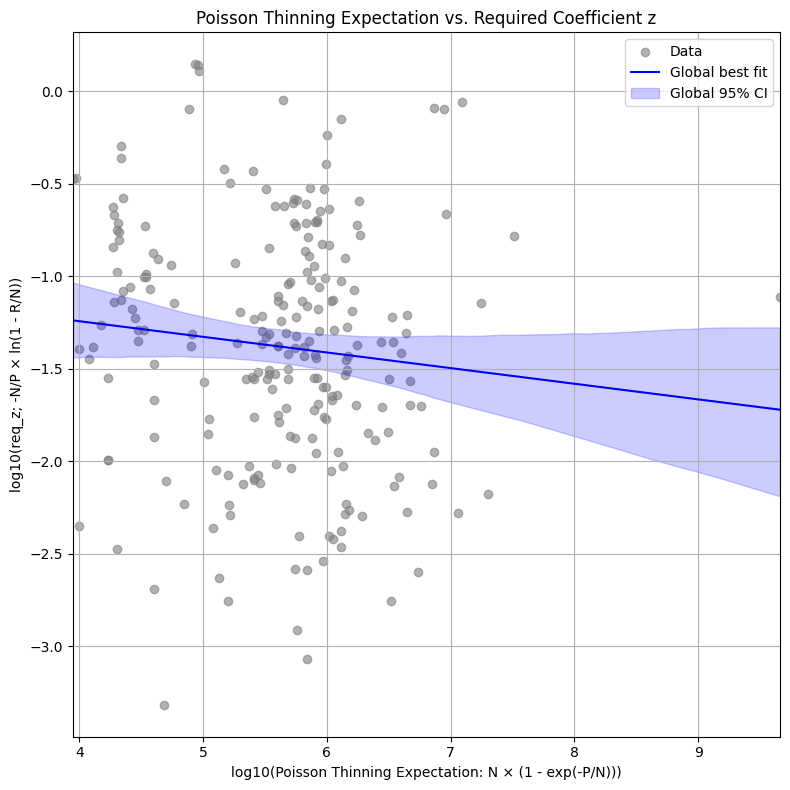

Global best fit slope: -0.0845
Global 95% bootstrap CI for slope: [-0.1950, 0.0247]
Global bootstrap R2 mean: 0.0151 (95% CI: 0.0000, 0.0529)


In [ ]:
# Cell 6: Plot log10(req_z) and Output Stats for Poisson Thinning

# Ensure pt_z and req_z are both from the same mask
pt_z = N_z * (1 - np.exp(-P_z / N_z))
# req_z already calculated above

# Jointly filter for valid (finite, positive) points
valid = (
    (~np.isnan(pt_z)) &
    (~np.isnan(req_z)) &
    (pt_z > 0) &
    (req_z > 0) &
    np.isfinite(pt_z) &
    np.isfinite(req_z)
)

x_z = np.log10(pt_z[valid])
y_req_z = np.log10(req_z[valid])

print("Filtered x_z length:", len(x_z))
print("Filtered y_req_z length:", len(y_req_z))

plt.figure(figsize=(8,8))
plt.scatter(x_z, y_req_z, alpha=0.6, label='Data', color='grey')
lims_z = [min(x_z), max(x_z)]
plt.xlim(lims_z)

slope_z, intercept_z = np.polyfit(x_z, y_req_z, 1)
n_bootstrap = 1000
slopes_z = []
intercepts_z = []
r2_z = []
from tqdm import trange
for _ in trange(n_bootstrap):
    idx = np.random.randint(0, len(x_z), len(x_z))
    x_sample = x_z[idx]
    y_sample = y_req_z[idx]
    s, b = np.polyfit(x_sample, y_sample, 1)
    slopes_z.append(s)
    intercepts_z.append(b)
    y_pred = s * x_sample + b
    ss_res = np.sum((y_sample - y_pred)**2)
    ss_tot = np.sum((y_sample - np.mean(y_sample))**2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
    r2_z.append(r2)

x_pred_z = np.linspace(lims_z[0], lims_z[1], 100)
y_pred_mat_z = np.array([s * x_pred_z + b for s, b in zip(slopes_z, intercepts_z)])
y_low_z, y_high_z = np.percentile(y_pred_mat_z, [2.5, 97.5], axis=0)
plt.plot(x_pred_z, slope_z * x_pred_z + intercept_z, color='blue', label='Global best fit')
plt.fill_between(x_pred_z, y_low_z, y_high_z, color='blue', alpha=0.2, label='Global 95% CI')
plt.xlabel('log10(Poisson Thinning Expectation: N × (1 - exp(-P/N)))')
plt.ylabel('log10(req_z; -N/P × ln(1 - R/N))')
plt.title('Poisson Thinning Expectation vs. Required Coefficient z')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/global_log10z_plot.pdf', bbox_inches='tight')
plt.show()

slope_z_lo, slope_z_hi = np.percentile(slopes_z, [2.5, 97.5])
r2_z_mean = np.nanmean(r2_z)
r2_z_lo, r2_z_hi = np.nanpercentile(r2_z, [2.5, 97.5])

print(f"Global best fit slope: {slope_z:.4f}")
print(f"Global 95% bootstrap CI for slope: [{slope_z_lo:.4f}, {slope_z_hi:.4f}]")
print(f"Global bootstrap R2 mean: {r2_z_mean:.4f} (95% CI: {r2_z_lo:.4f}, {r2_z_hi:.4f})")




Mean log10(req_z):   -1.3785 [-1.4597, -1.2983]
Median log10(req_z): -1.3525 [-1.4298, -1.2751]
Mode log10(req_z):   -1.3594 [-1.5514, -0.9799]


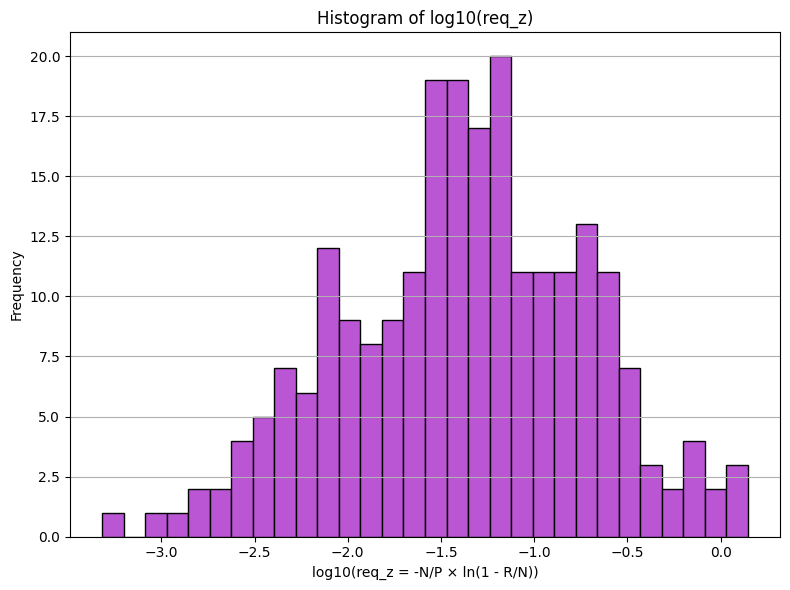

In [ ]:
# Cell 8: Plot histogram of req_z frequencies (Poisson thinning model)

# Filter req_z values
zvals = req_z               # Already filtered by mask_z in earlier block
zvals = zvals[zvals > 0]    # Only positive values
logz = np.log10(zvals)
n_bootstrap = 1000

# Bootstrapped mean, median, mode
means = []
medians = []
modes = []

for _ in range(n_bootstrap):
    sample = np.random.choice(logz, size=len(logz), replace=True)
    means.append(np.mean(sample))
    medians.append(np.median(sample))
    hist, bin_edges = np.histogram(sample, bins=30)
    mode_idx = np.argmax(hist)
    mode_val = (bin_edges[mode_idx] + bin_edges[mode_idx + 1]) / 2
    modes.append(mode_val)

mean_val = np.mean(means)
mean_lo, mean_hi = np.percentile(means, [2.5, 97.5])
median_val = np.mean(medians)
median_lo, median_hi = np.percentile(medians, [2.5, 97.5])
mode_val = np.mean(modes)
mode_lo, mode_hi = np.percentile(modes, [2.5, 97.5])

print(f"Mean log10(req_z):   {mean_val:.4f} [{mean_lo:.4f}, {mean_hi:.4f}]")
print(f"Median log10(req_z): {median_val:.4f} [{median_lo:.4f}, {median_hi:.4f}]")
print(f"Mode log10(req_z):   {mode_val:.4f} [{mode_lo:.4f}, {mode_hi:.4f}]")

# Histogram plot
plt.figure(figsize=(8,6))
plt.hist(logz, bins=30, color='mediumorchid', edgecolor='black')
plt.xlabel('log10(req_z = -N/P × ln(1 - R/N))')
plt.ylabel('Frequency')
plt.title('Histogram of log10(req_z)')
plt.grid(axis='y')
plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/z_histogram.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()


log10(req_z) Bootstrapped Slopes & R2:
Estuary   : slope=-0.504 [-0.999,0.041], R2=0.191 [0.002,0.559], n=46
Lagoon    : slope=0.148 [-0.147,0.582], R2=0.497 [0.005,0.946], n=7
Lake      : slope=-0.400 [-0.843,-0.156], R2=0.614 [0.116,0.949], n=7
Ocean     : slope=-0.139 [-0.278,0.011], R2=0.028 [0.000,0.088], n=164


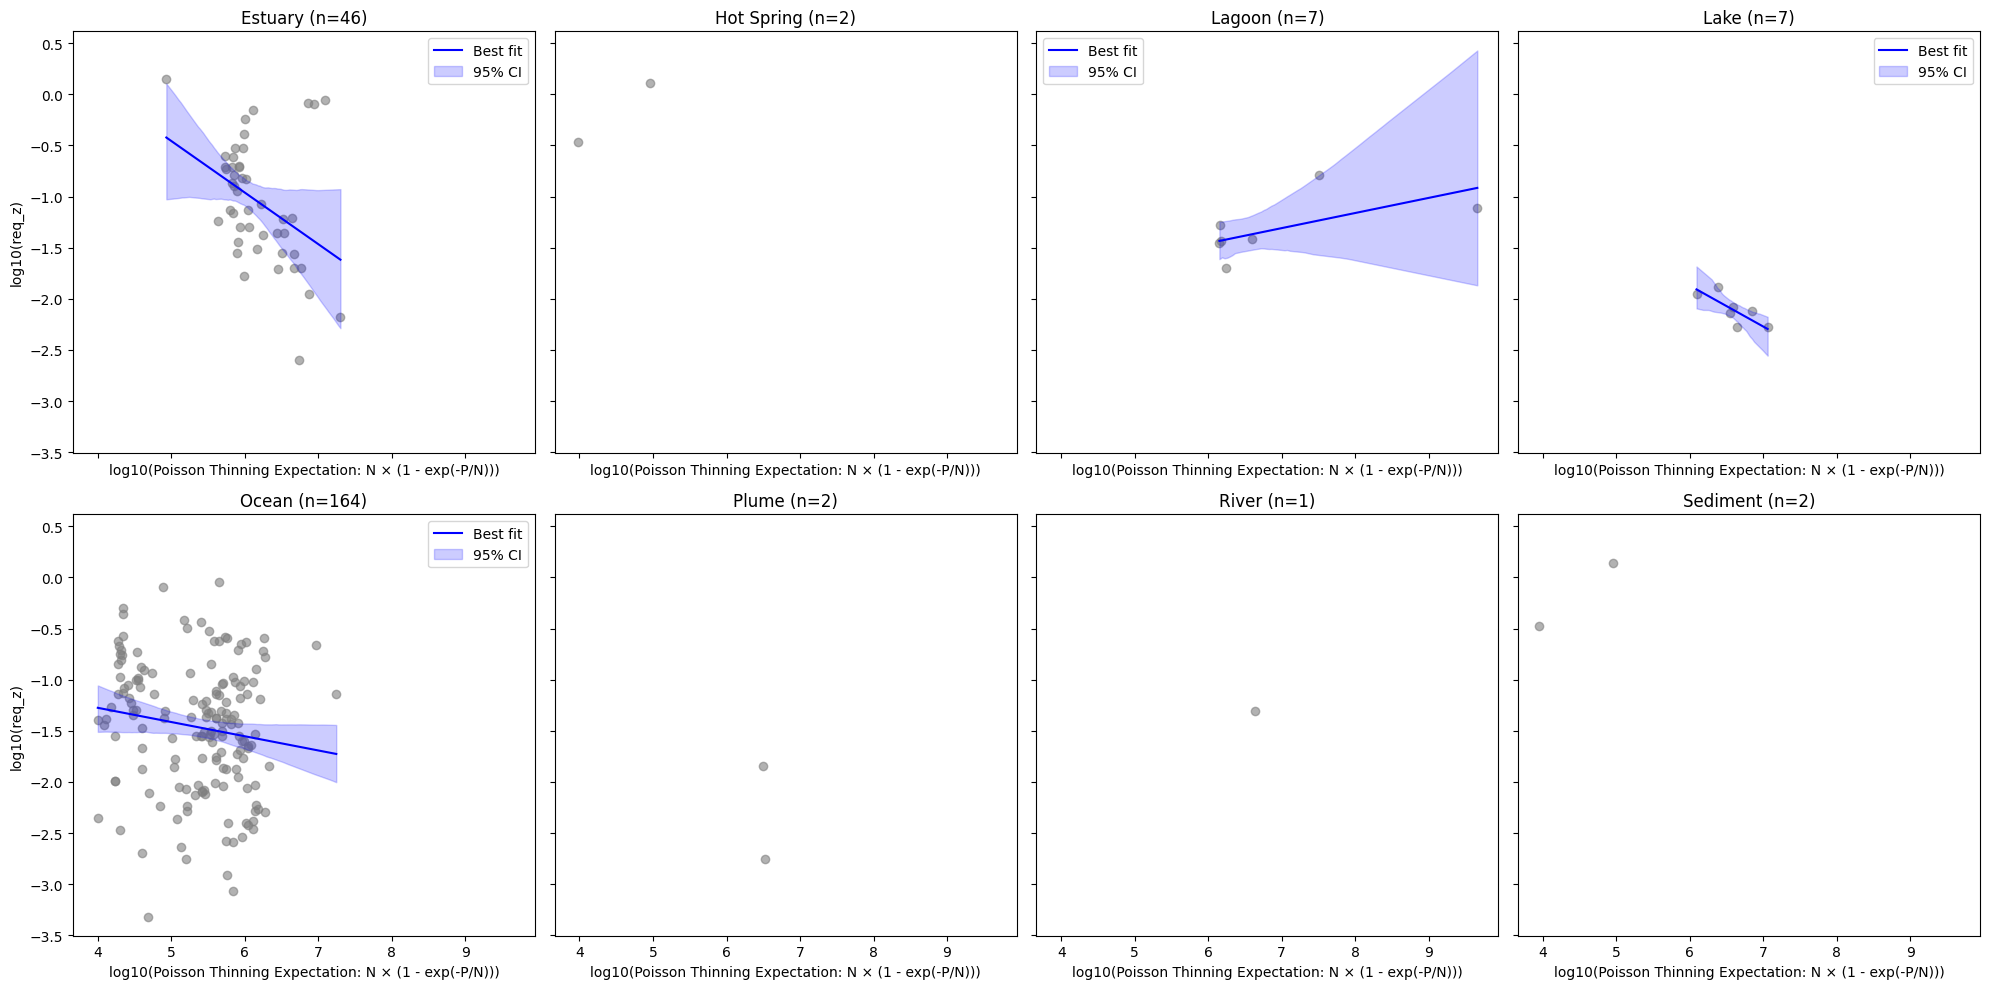

In [ ]:
# Cell 10: Faceting req_z plots by environment (Poisson thinning driver)

import numpy as np
import matplotlib.pyplot as plt

# Jointly filter for valid (finite, positive) pt_z and req_z
valid = (
    (~np.isnan(pt_z)) &
    (~np.isnan(req_z)) &
    (pt_z > 0) &
    (req_z > 0) &
    np.isfinite(pt_z) &
    np.isfinite(req_z)
)
env_filtered = df.loc[mask_z, 'Environment'].values[valid]
x_panel = np.log10(pt_z[valid])
y_panel = np.log10(req_z[valid])

env_list = np.unique(env_filtered)
ncol = 4
nrow = int(np.ceil(len(env_list) / ncol))
n_bootstrap = 1000

fig, axes = plt.subplots(nrow, ncol, figsize=(5*ncol, 5*nrow), sharex=True, sharey=True)
axes = axes.flatten()

print('log10(req_z) Bootstrapped Slopes & R2:')
for i, e in enumerate(env_list):
    idx = np.where(env_filtered == e)[0]
    ax = axes[i]
    x_env = x_panel[idx]
    y_env = y_panel[idx]
    ax.scatter(x_env, y_env, color='grey', alpha=0.6)
    ax.set_title(f"{e} (n={len(x_env)})")
    ax.set_xlabel('log10(Poisson Thinning Expectation: N × (1 - exp(-P/N)))')
    if i % ncol == 0:
        ax.set_ylabel('log10(req_z)')

    # Best fit if n>=5
    if len(x_env) >= 5:
        slopes = []
        intercepts = []
        r2s = []
        for _ in range(n_bootstrap):
            boot_idx = np.random.randint(0, len(x_env), len(x_env))
            x_boot = x_env[boot_idx]
            y_boot = y_env[boot_idx]
            s, b = np.polyfit(x_boot, y_boot, 1)
            slopes.append(s)
            intercepts.append(b)
            y_pred = s * x_boot + b
            ss_res = np.sum((y_boot - y_pred) ** 2)
            ss_tot = np.sum((y_boot - np.mean(y_boot)) ** 2)
            r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan
            r2s.append(r2)
        mean_slope = np.mean(slopes)
        mean_intercept = np.mean(intercepts)
        slope_lo, slope_hi = np.percentile(slopes, [2.5, 97.5])
        r2_mean = np.nanmean(r2s)
        r2_lo, r2_hi = np.nanpercentile(r2s, [2.5, 97.5])
        x_pred = np.linspace(min(x_env), max(x_env), 100)
        y_pred_mat = np.array([s * x_pred + b for s, b in zip(slopes, intercepts)])
        y_low, y_high = np.percentile(y_pred_mat, [2.5, 97.5], axis=0)
        ax.plot(x_pred, mean_slope * x_pred + mean_intercept, color='blue', label='Best fit')
        ax.fill_between(x_pred, y_low, y_high, color='blue', alpha=0.2, label='95% CI')
        ax.legend()
        print(f"{e:10}: slope={mean_slope:.3f} [{slope_lo:.3f},{slope_hi:.3f}], "
              f"R2={r2_mean:.3f} [{r2_lo:.3f},{r2_hi:.3f}], n={len(x_env)}")

# Hide empty panels
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
save_path = '/content/drive/My Drive/Hopeful Monsters/Projects/Mass Action 2025/Datasets/Viruses/logz_env_panel.pdf'
plt.savefig(save_path, bbox_inches='tight')
plt.show()
